<a href="https://colab.research.google.com/github/Muhammad-Musharraf/Machine-Learning/blob/main/Sentimental_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
df=pd.read_csv("/content/drive/MyDrive/IMDB Dataset (1).csv",on_bad_lines='skip')

In [4]:
df.head()

,review,sentiment
0,One of the other reviewers has mentioned that ...,positive
1,A wonderful little production. <br /><br />The...,positive
2,I thought this was a wonderful way to spend ti...,positive
3,Basically there's a family where a little boy ...,negative
4,"Petter Mattei's ""Love in the Time of Money"" is...",positive


#Data Cleaning

In [5]:
df.shape

(50000, 2)

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 2 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   review     50000 non-null  object
 1   sentiment  50000 non-null  object
dtypes: object(2)
memory usage: 781.4+ KB


In [7]:
df.isnull().sum()

,0
review,0
sentiment,0


In [8]:
df.duplicated().sum()

np.int64(418)

In [9]:
df.drop_duplicates(keep='first', inplace=True)


In [10]:
df.shape

(49582, 2)

# Label Encoding On Sentiment Column
jab target column means output hamara nomianl hu.

In [11]:
from sklearn.preprocessing import LabelEncoder

In [12]:
le=LabelEncoder()

In [13]:
df['sentiment']=le.fit_transform(df['sentiment'])
df.head()

,review,sentiment
0,One of the other reviewers has mentioned that ...,1
1,A wonderful little production. <br /><br />The...,1
2,I thought this was a wonderful way to spend ti...,1
3,Basically there's a family where a little boy ...,0
4,"Petter Mattei's ""Love in the Time of Money"" is...",1


#EDA

In [14]:
df['sentiment'].value_counts()

,count
sentiment,
1,24884
0,24698


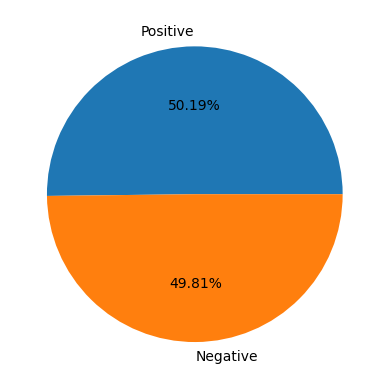

In [15]:
plt.pie(df['sentiment'].value_counts(),labels=['Positive','Negative'],autopct='%1.2f%%')
plt.show()

In [16]:
import nltk
nltk.download('punkt_tab')

[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


True

In [17]:
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
nltk.download('stopwords')

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


True

In [18]:
#making the new column of "no of characters" of each review record

df['num_characters']=df['review'].apply(len)
df.head()

,review,sentiment,num_characters
0,One of the other reviewers has mentioned that ...,1,1761
1,A wonderful little production. <br /><br />The...,1,998
2,I thought this was a wonderful way to spend ti...,1,926
3,Basically there's a family where a little boy ...,0,748
4,"Petter Mattei's ""Love in the Time of Money"" is...",1,1317


In [19]:
# make a new column for "no of words" in each review record
df['num words']=df['review'].apply(lambda x:len(word_tokenize(x)))
df.head()

,review,sentiment,num_characters,num words
0,One of the other reviewers has mentioned that ...,1,1761,380
1,A wonderful little production. <br /><br />The...,1,998,201
2,I thought this was a wonderful way to spend ti...,1,926,205
3,Basically there's a family where a little boy ...,0,748,175
4,"Petter Mattei's ""Love in the Time of Money"" is...",1,1317,283


In [20]:
# make a new column for "no of sentences" in each review record
df['num_sentences']=df['review'].apply(lambda x:len(x.split('.')))
df.head()

,review,sentiment,num_characters,num words,num_sentences
0,One of the other reviewers has mentioned that ...,1,1761,380,27
1,A wonderful little production. <br /><br />The...,1,998,201,7
2,I thought this was a wonderful way to spend ti...,1,926,205,7
3,Basically there's a family where a little boy ...,0,748,175,11
4,"Petter Mattei's ""Love in the Time of Money"" is...",1,1317,283,16


<Axes: xlabel='num_characters', ylabel='Count'>

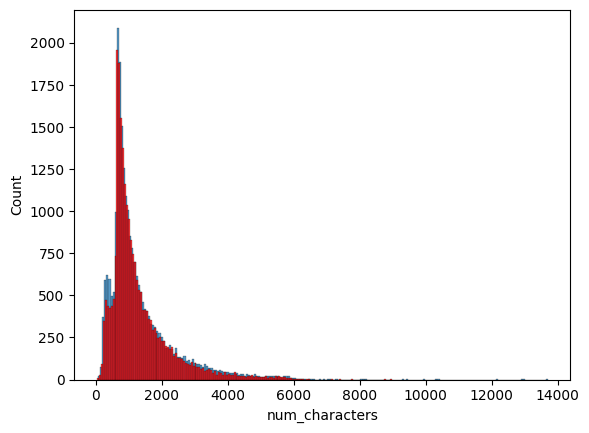

In [21]:
#Plotting histogram on positive and negative reviews
sns.histplot(df[df['sentiment']==1]['num_characters'])
sns.histplot(df[df['sentiment']==0]['num_characters'],color='red')

<Axes: xlabel='num words', ylabel='Count'>

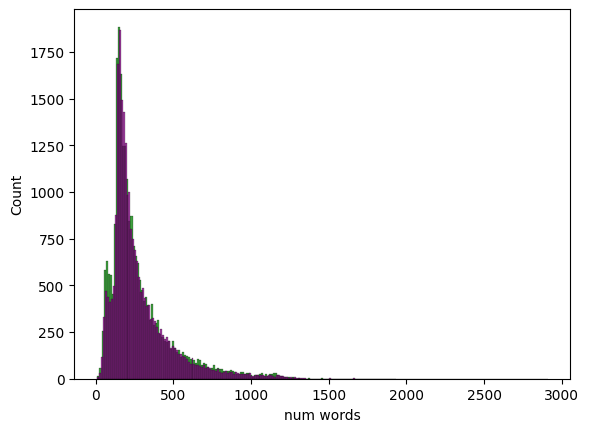

In [22]:
#Plotting histogram on positive and negative reviews
sns.histplot(df[df['sentiment']==1]['num words'],color='green')
sns.histplot(df[df['sentiment']==0]['num words'],color='purple')


<Axes: xlabel='num_sentences', ylabel='Count'>

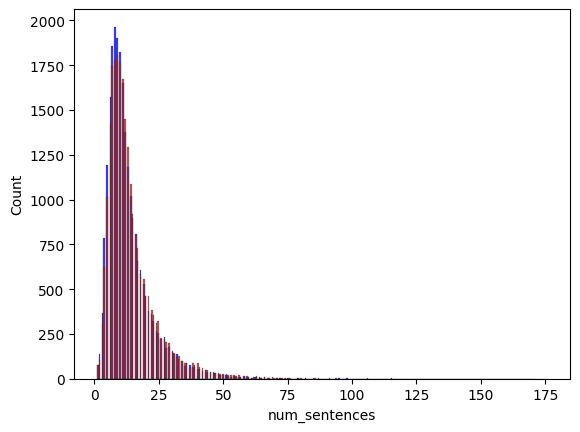

In [23]:
#Plotting histogram on positive and negative reviews
sns.histplot(df[df['sentiment']==1]['num_sentences'],color='blue')
sns.histplot(df[df['sentiment']==0]['num_sentences'],color='brown')

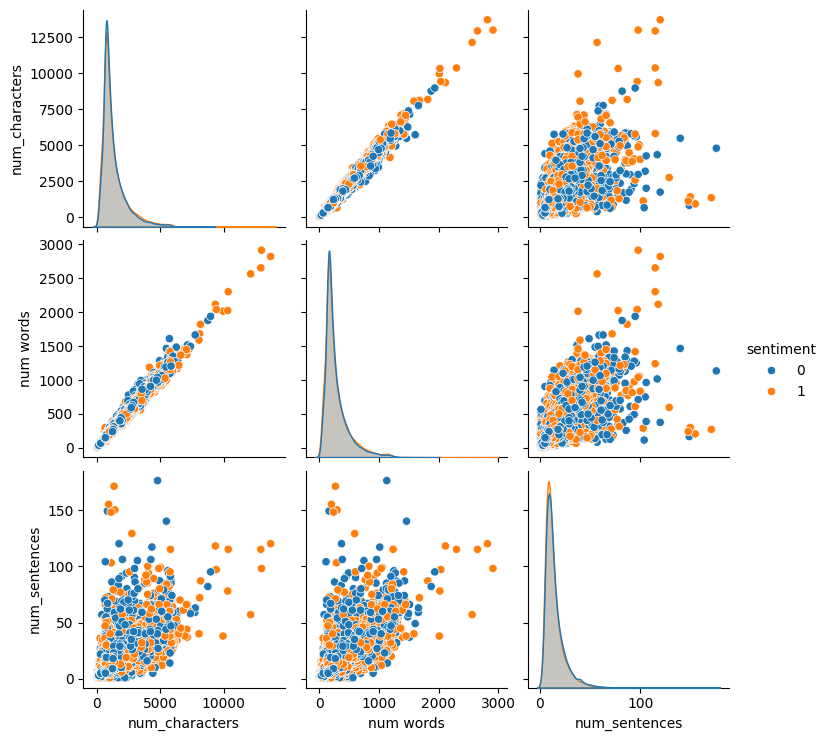

In [24]:
# Relationships
sns.pairplot(df,hue='sentiment')
plt.show()

In [25]:
df.corr(numeric_only=True)

,sentiment,num_characters,num words,num_sentences
sentiment,1.000000,0.015917,0.004498,-0.035255
num_characters,0.015917,1.000000,0.994587,0.772756
num words,0.004498,0.994587,1.000000,0.793276
num_sentences,-0.035255,0.772756,0.793276,1.000000


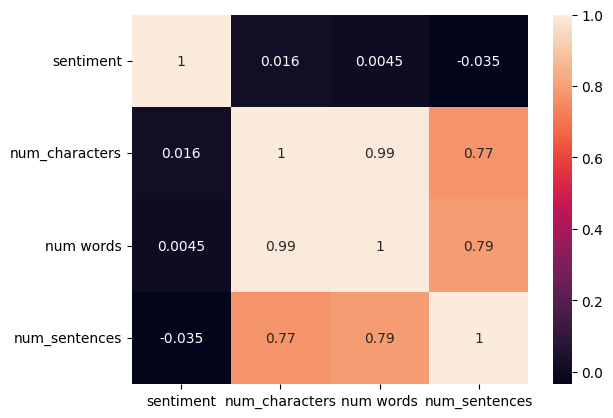

In [26]:
sns.heatmap(df.corr(numeric_only=True),annot=True)
plt.show()

# Data Processing on Reviews

1. Remove chatwords
2. Remove Html Tags
3. Remove Url's
4. remove Punctuations
5. Text to Lowercase
6. Remove Stopwords
7. tokenaization

In [27]:
# 1.Remove chatwords
chatwords= {
    "AFAIK": "As Far As I Know",
    "AFK": "Away From Keyboard",
    "ASAP": "As Soon As Possible",
    "ATK": "At The Keyboard",
    "ATM": "At The Moment",
    "A3": "Anytime, Anywhere, Anyplace",
    "BAK": "Back At Keyboard",
    "BBL": "Be Back Later",
    "BBS": "Be Back Soon",
    "BFN": "Bye For Now",
    "B4N": "Bye For Now",
    "BRB": "Be Right Back",
    "BRT": "Be Right There",
    "BTW": "By The Way",
    "B4": "Before",
    "B4N": "Bye For Now",
    "CU": "See You",
    "CUL8R": "See You Later",
    "CYA": "See You",
    "FAQ": "Frequently Asked Questions",
    "FC": "Fingers Crossed",
    "FWIW": "For What It's Worth",
    "FYI": "For Your Information",
    "GAL": "Get A Life",
    "GG": "Good Game",
    "GN": "Good Night",
    "GMTA": "Great Minds Think Alike",
    "GR8": "Great!",
    "G9": "Genius",
    "IC": "I See",
    "ICQ": "I Seek you (also a chat program)",
    "ILU": "ILU: I Love You",
    "IMHO": "In My Honest/Humble Opinion",
    "IMO": "In My Opinion",
    "IOW": "In Other Words",
    "IRL": "In Real Life",
    "KISS": "Keep It Simple, Stupid",
    "LDR": "Long Distance Relationship",
    "LMAO": "Laugh My A.. Off",
    "LOL": "Laughing Out Loud",
    "LTNS": "Long Time No See",
    "L8R": "Later",
    "MTE": "My Thoughts Exactly",
    "M8": "Mate",
    "NRN": "No Reply Necessary",
    "OIC": "Oh I See",
    "PITA": "Pain In The A..",
    "PRT": "Party",
    "PRW": "Parents Are Watching",
    "QPSA": "Que Pasa?",
    "ROFL": "Rolling On The Floor Laughing",
    "ROFLOL": "Rolling On The Floor Laughing Out Loud",
    "ROTFLMAO": "Rolling On The Floor Laughing My A.. Off",
    "SK8": "Skate",
    "STATS": "Your sex and age",
    "ASL": "Age, Sex, Location",
    "THX": "Thank You",
    "TTFN": "Ta-Ta For Now!",
    "TTYL": "Talk To You Later",
    "U": "You",
    "U2": "You Too",
    "U4E": "Yours For Ever",
    "WB": "Welcome Back",
    "WTF": "What The F...",
    "WTG": "Way To Go!",
    "WUF": "Where Are You From?",
    "W8": "Wait...",
    "7K": "Sick:-D Laugher",
    "TFW": "That feeling when",
    "MFW": "My face when",
    "MRW": "My reaction when",
    "IFYP": "I feel your pain",
    "LOL": "Laughing out loud",
    "TNTL": "Trying not to laugh",
    "JK": "Just kidding",
    "IDC": "I don’t care",
    "ILY": "I love you",
    "IMU": "I miss you",
    "ADIH": "Another day in hell",
    "IDC": "I don’t care",
    "ZZZ": "Sleeping, bored, tired",
    "WYWH": "Wish you were here",
    "TIME": "Tears in my eyes",
    "BAE": "Before anyone else",
    "FIMH": "Forever in my heart",
    "BSAAW": "Big smile and a wink",
    "BWL": "Bursting with laughter",
    "LMAO": "Laughing my a** off",
    "BFF": "Best friends forever",
    "CSL": "Can’t stop laughing"
}
print(chatwords)

{'AFAIK': 'As Far As I Know', 'AFK': 'Away From Keyboard', 'ASAP': 'As Soon As Possible', 'ATK': 'At The Keyboard', 'ATM': 'At The Moment', 'A3': 'Anytime, Anywhere, Anyplace', 'BAK': 'Back At Keyboard', 'BBL': 'Be Back Later', 'BBS': 'Be Back Soon', 'BFN': 'Bye For Now', 'B4N': 'Bye For Now', 'BRB': 'Be Right Back', 'BRT': 'Be Right There', 'BTW': 'By The Way', 'B4': 'Before', 'CU': 'See You', 'CUL8R': 'See You Later', 'CYA': 'See You', 'FAQ': 'Frequently Asked Questions', 'FC': 'Fingers Crossed', 'FWIW': "For What It's Worth", 'FYI': 'For Your Information', 'GAL': 'Get A Life', 'GG': 'Good Game', 'GN': 'Good Night', 'GMTA': 'Great Minds Think Alike', 'GR8': 'Great!', 'G9': 'Genius', 'IC': 'I See', 'ICQ': 'I Seek you (also a chat program)', 'ILU': 'ILU: I Love You', 'IMHO': 'In My Honest/Humble Opinion', 'IMO': 'In My Opinion', 'IOW': 'In Other Words', 'IRL': 'In Real Life', 'KISS': 'Keep It Simple, Stupid', 'LDR': 'Long Distance Relationship', 'LMAO': 'Laughing my a** off', 'LOL': 'L

In [28]:
def chat_conversaion(text):
  new_text=[]
  for word in text.split():
    if word.upper() in chatwords:
      new_text.append(chatwords[word.upper()])
    else:
      new_text.append(word)
  return " ".join(new_text)



In [29]:
chat_conversaion('IMHO he is the best')


'In My Honest/Humble Opinion he is the best'

In [30]:
df['review']=df['review'].apply(chat_conversaion)
df.head()

,review,sentiment,num_characters,num words,num_sentences
0,One of the other reviewers has mentioned that ...,1,1761,380,27
1,A wonderful little production. <br /><br />The...,1,998,201,7
2,I thought this was a wonderful way to spend Te...,1,926,205,7
3,Basically there's a family where a little boy ...,0,748,175,11
4,"Petter Mattei's ""Love in the Tears in my eyes ...",1,1317,283,16


#2. Remove HTML Tags

In [31]:
# remove html tags
import re
def remove_html(text):
  clean=re.compile('<.*?>')
  return re.sub(clean,'',text)



In [32]:
text="<h2>Design & Comfortable </h2>"
remove_html(text)

'Design & Comfortable '

In [33]:
df['review']=df['review'].apply(remove_html)
df.head()

,review,sentiment,num_characters,num words,num_sentences
0,One of the other reviewers has mentioned that ...,1,1761,380,27
1,A wonderful little production. The filming tec...,1,998,201,7
2,I thought this was a wonderful way to spend Te...,1,926,205,7
3,Basically there's a family where a little boy ...,0,748,175,11
4,"Petter Mattei's ""Love in the Tears in my eyes ...",1,1317,283,16


In [34]:
df['review'][4]

'Petter Mattei\'s "Love in the Tears in my eyes of Money" is a visually stunning film to watch. Mr. Mattei offers us a vivid portrait about human relations. This is a movie that seems to be telling us what money, power and success do to people in the different situations we encounter. This being a variation on the Arthur Schnitzler\'s play about the same theme, the director transfers the action to the present Tears in my eyes New York where all these different characters meet and connect. Each one is connected in one way, or another to the next person, but no one seems to know the previous point of contact. Stylishly, the film has a sophisticated luxurious look. We are taken to see how these people live and the world they live in their own habitat.The only thing one gets out of all these souls in the picture is the different stages of loneliness each one inhabits. A big city is not exactly the best place in which human relations find sincere fulfillment, as one discerns is the case wit

#3. Remove URL'S

In [35]:
# 3. remove Urls
def remove_urls(text):
  url=re.compile(r'https?://\S+|www\.\S+')
  return url.sub(r"",text)


In [36]:
text="https://www.facebook.com/ FaceBook is a social media website"
remove_urls(text)

' FaceBook is a social media website'

In [37]:
df['review']=df['review'].apply(remove_urls)
df.head()

,review,sentiment,num_characters,num words,num_sentences
0,One of the other reviewers has mentioned that ...,1,1761,380,27
1,A wonderful little production. The filming tec...,1,998,201,7
2,I thought this was a wonderful way to spend Te...,1,926,205,7
3,Basically there's a family where a little boy ...,0,748,175,11
4,"Petter Mattei's ""Love in the Tears in my eyes ...",1,1317,283,16


#4. Remove Punctuations


In [38]:
# 4.Remove Punctatuations
import string
string.punctuation

'!"#$%&\'()*+,-./:;<=>?@[\\]^_`{|}~'

In [39]:
def remove_punctuation(text):
  punctuations=string.punctuation
  no_punctuations="".join(char for char in text if char not in punctuations)
  return no_punctuations

In [40]:
text = "hello, how are you?"
print(remove_punctuation(text))

hello how are you


In [41]:
df['review']=df['review'].apply(remove_punctuation)
df.head()

,review,sentiment,num_characters,num words,num_sentences
0,One of the other reviewers has mentioned that ...,1,1761,380,27
1,A wonderful little production The filming tech...,1,998,201,7
2,I thought this was a wonderful way to spend Te...,1,926,205,7
3,Basically theres a family where a little boy J...,0,748,175,11
4,Petter Matteis Love in the Tears in my eyes of...,1,1317,283,16


In [42]:
df['review'][4]

'Petter Matteis Love in the Tears in my eyes of Money is a visually stunning film to watch Mr Mattei offers us a vivid portrait about human relations This is a movie that seems to be telling us what money power and success do to people in the different situations we encounter This being a variation on the Arthur Schnitzlers play about the same theme the director transfers the action to the present Tears in my eyes New York where all these different characters meet and connect Each one is connected in one way or another to the next person but no one seems to know the previous point of contact Stylishly the film has a sophisticated luxurious look We are taken to see how these people live and the world they live in their own habitatThe only thing one gets out of all these souls in the picture is the different stages of loneliness each one inhabits A big city is not exactly the best place in which human relations find sincere fulfillment as one discerns is the case with most of the people 

#5. Text LowerCase

In [43]:
df['review']=df['review'].str.lower()
df.head()

,review,sentiment,num_characters,num words,num_sentences
0,one of the other reviewers has mentioned that ...,1,1761,380,27
1,a wonderful little production the filming tech...,1,998,201,7
2,i thought this was a wonderful way to spend te...,1,926,205,7
3,basically theres a family where a little boy j...,0,748,175,11
4,petter matteis love in the tears in my eyes of...,1,1317,283,16


In [44]:
df['review'][8]

'encouraged by the positive comments about this film on here i was looking forward to watching this film bad mistake ive seen 950 films and this is truly one of the worst of them  its awful in almost every way editing pacing storyline acting soundtrack the films only song  a lame country tune  is played no less than four times the film looks cheap and nasty and is boring in the extreme rarely have i been so happy to see the end credits of a film the only thing that prevents me giving this a 1score is harvey keitel  while this is far from his best performance he at least seems to be making a bit of an effort one for keitel obsessives only'

#6. Remove Stopwords

In [45]:
# 6  Remove Stopwords
from nltk.corpus import stopwords
nltk.download('stopwords')
stopwords.words('english')

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


['a',
 'about',
 'above',
 'after',
 'again',
 'against',
 'ain',
 'all',
 'am',
 'an',
 'and',
 'any',
 'are',
 'aren',
 "aren't",
 'as',
 'at',
 'be',
 'because',
 'been',
 'before',
 'being',
 'below',
 'between',
 'both',
 'but',
 'by',
 'can',
 'couldn',
 "couldn't",
 'd',
 'did',
 'didn',
 "didn't",
 'do',
 'does',
 'doesn',
 "doesn't",
 'doing',
 'don',
 "don't",
 'down',
 'during',
 'each',
 'few',
 'for',
 'from',
 'further',
 'had',
 'hadn',
 "hadn't",
 'has',
 'hasn',
 "hasn't",
 'have',
 'haven',
 "haven't",
 'having',
 'he',
 "he'd",
 "he'll",
 'her',
 'here',
 'hers',
 'herself',
 "he's",
 'him',
 'himself',
 'his',
 'how',
 'i',
 "i'd",
 'if',
 "i'll",
 "i'm",
 'in',
 'into',
 'is',
 'isn',
 "isn't",
 'it',
 "it'd",
 "it'll",
 "it's",
 'its',
 'itself',
 "i've",
 'just',
 'll',
 'm',
 'ma',
 'me',
 'mightn',
 "mightn't",
 'more',
 'most',
 'mustn',
 "mustn't",
 'my',
 'myself',
 'needn',
 "needn't",
 'no',
 'nor',
 'not',
 'now',
 'o',
 'of',
 'off',
 'on',
 'once',
 'on

In [46]:
eng_stopwords=stopwords.words('english')

In [47]:
lst=[]
def remove_stopwords(text):
  filtered=[word for word in text.split() if word not in eng_stopwords]
  return " ".join(filtered)

In [48]:
import nltk
from nltk.corpus import stopwords

# Get the list of English stopwords
english_stop_words = stopwords.words('english')

# Apply stopword removal using a lambda function
df['review'] = df['review'].apply(remove_stopwords)


#7. tokenization





In [49]:
# 7. tokenization
def tokenization(text):
  word_token=word_tokenize(text)
  return word_token

In [50]:
df['tokenized_review']=df['review'].apply(tokenization)


In [51]:
df.head()

,review,sentiment,num_characters,num words,num_sentences,tokenized_review
0,one reviewers mentioned watching 1 oz episode ...,1,1761,380,27,"[one, reviewers, mentioned, watching, 1, oz, e..."
1,wonderful little production filming technique ...,1,998,201,7,"[wonderful, little, production, filming, techn..."
2,thought wonderful way spend tears eyes hot sum...,1,926,205,7,"[thought, wonderful, way, spend, tears, eyes, ..."
3,basically theres family little boy jake thinks...,0,748,175,11,"[basically, theres, family, little, boy, jake,..."
4,petter matteis love tears eyes money visually ...,1,1317,283,16,"[petter, matteis, love, tears, eyes, money, vi..."


In [52]:
# Convert tokenized_review to strings
df['tokenized_review_str'] = df['tokenized_review'].apply(lambda tokens: ' '.join(tokens))

In [53]:
df.head()

,review,sentiment,num_characters,num words,num_sentences,tokenized_review,tokenized_review_str
0,one reviewers mentioned watching 1 oz episode ...,1,1761,380,27,"[one, reviewers, mentioned, watching, 1, oz, e...",one reviewers mentioned watching 1 oz episode ...
1,wonderful little production filming technique ...,1,998,201,7,"[wonderful, little, production, filming, techn...",wonderful little production filming technique ...
2,thought wonderful way spend tears eyes hot sum...,1,926,205,7,"[thought, wonderful, way, spend, tears, eyes, ...",thought wonderful way spend tears eyes hot sum...
3,basically theres family little boy jake thinks...,0,748,175,11,"[basically, theres, family, little, boy, jake,...",basically theres family little boy jake thinks...
4,petter matteis love tears eyes money visually ...,1,1317,283,16,"[petter, matteis, love, tears, eyes, money, vi...",petter matteis love tears eyes money visually ...


In [54]:
df['tokenized_review_str']

,tokenized_review_str
0,one reviewers mentioned watching 1 oz episode ...
1,wonderful little production filming technique ...
2,thought wonderful way spend tears eyes hot sum...
3,basically theres family little boy jake thinks...
4,petter matteis love tears eyes money visually ...
...,...
49995,thought movie right good job wasnt creative or...
49996,bad plot bad dialogue bad acting idiotic direc...
49997,catholic taught parochial elementary schools n...
49998,im going disagree previous comment side maltin...


In [55]:
# Making Wordcloud for words
from wordcloud import WordCloud
wc=WordCloud(height=500,width=500,min_font_size=10,background_color='black')


In [56]:
#for positive reviews
positive_wc=wc.generate(df[df['sentiment']==1]['tokenized_review_str'].str.cat(sep=" "))

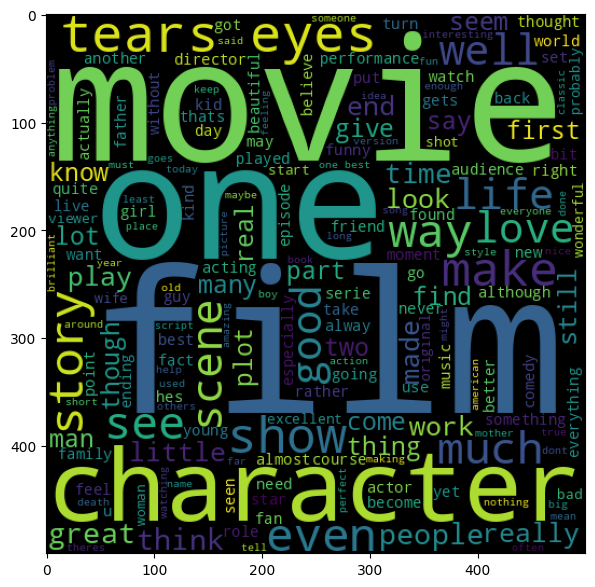

In [57]:
# making wordcloud
plt.figure(figsize=(16,7))
plt.imshow(positive_wc)


In [58]:
#for negative reviews
negative_wc=wc.generate(df[df['sentiment']==0]['tokenized_review_str'].str.cat(sep=" "))


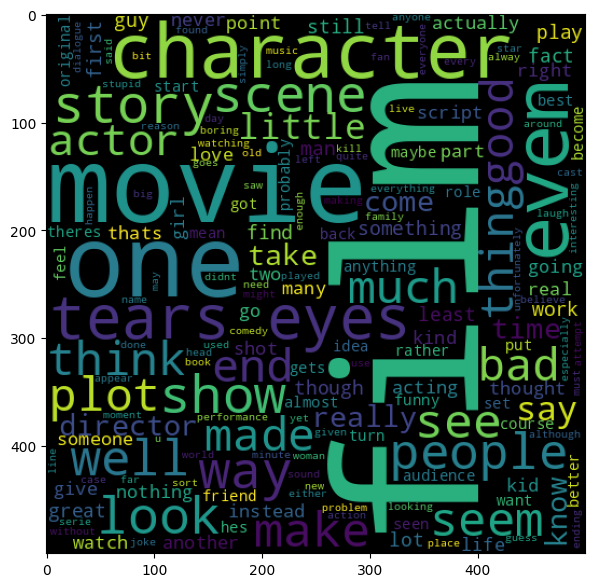

In [59]:

plt.figure(figsize=(16,7))
plt.imshow(negative_wc)


OneHotEncoding
bag of words
term frequency ----> tell how many the words in a sentence
inververse documents frequency----> tells ho many words in overall documents

# Feature Extraction

In [60]:
from sklearn.feature_extraction.text import TfidfVectorizer

vectorizer=TfidfVectorizer(dtype=int)

In [61]:
x=vectorizer.fit_transform(df['review'])

/usr/local/lib/python3.12/dist-packages/sklearn/feature_extraction/text.py:2043: UserWarning: Only (<class 'numpy.float64'>, <class 'numpy.float32'>, <class 'numpy.float16'>) 'dtype' should be used. <class 'int'> 'dtype' will be converted to np.float64.
  warnings.warn(


In [62]:
x.shape

(49582, 221213)

In [63]:
y=df['sentiment']

In [64]:
from sklearn.model_selection import train_test_split

In [65]:
#Split dataset into train and test
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=100)

# Classification
1. Native Bayes
2. logistics Regession
3. Support Vector Machine


In [66]:
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC

In [67]:
svc=SVC(kernel='sigmoid',gamma=1.0)
mnb=MultinomialNB()
lrc=LogisticRegression(solver='liblinear',penalty='l1')

In [68]:
classifiers={
    'SVC':svc,
    'MNB':mnb,
    'LR':lrc

}

In [69]:
from sklearn.metrics import accuracy_score,precision_score,recall_score,f1_score,confusion_matrix

In [70]:
def train_classifier(classifiers,x_train, y_train, x_test, y_test):

  classifiers.fit(x_train,y_train)
  y_pred=classifiers.predict(x_test)

  accuracy=accuracy_score(y_test,y_pred)
  precision=precision_score(y_test,y_pred)
  recall = recall_score(y_test, y_pred)
  f1 = f1_score(y_test, y_pred)
  confusion = confusion_matrix(y_test, y_pred)


  return accuracy,precision,recall,f1,confusion

# Model Performance And Evaluation

In [71]:
accuracy_scores=[]
precision_scores=[]
recall_scores=[]
f1_scores=[]

for name, clf in classifiers.items():
    current_accuracy,current_precision,current_recall,current_f1,current_confusion=train_classifier(clf,x_train,y_train,x_test,y_test)

    print('Name',name)
    print('Accuracy ',current_accuracy)
    print('Precision ',current_precision)
    print('Recall ',current_recall)
    print('F1 ',current_f1)
    print('Confusion ',current_confusion)

    accuracy_scores.append(current_accuracy)
    precision_scores.append(current_precision)
    recall_scores.append(current_recall)
    f1_scores.append(current_f1)


Name SVC
Accuracy  0.8957345971563981
Precision  0.89217425586438
Recall  0.902852583283463
F1  0.8974816577434067
Confusion  [[4357  547]
 [ 487 4526]]
Name MNB
Accuracy  0.8643743067459917
Precision  0.8742857142857143
Recall  0.8545780969479354
F1  0.8643195803490367
Confusion  [[4288  616]
 [ 729 4284]]
Name LR
Accuracy  0.8821216093576687
Precision  0.8767150137201097
Recall  0.8922800718132855
F1  0.8844290657439446
Confusion  [[4275  629]
 [ 540 4473]]


In [73]:
performance_df=pd.DataFrame({'Algorithm':classifiers.keys(),'Accuracy':accuracy_scores,'Precision':precision_scores,'Recall':recall_scores,'F1':f1_scores})

In [74]:
performance_df

,Algorithm,Accuracy,Precision,Recall,F1
0,SVC,0.895735,0.892174,0.902853,0.897482
1,MNB,0.864374,0.874286,0.854578,0.864320
2,LR,0.882122,0.876715,0.892280,0.884429


In [75]:
performance_df1=pd.melt(performance_df,id_vars='Algorithm')
performance_df1

,Algorithm,variable,value
0,SVC,Accuracy,0.895735
1,MNB,Accuracy,0.864374
2,LR,Accuracy,0.882122
3,SVC,Precision,0.892174
4,MNB,Precision,0.874286
5,LR,Precision,0.876715
6,SVC,Recall,0.902853
7,MNB,Recall,0.854578
8,LR,Recall,0.892280
9,SVC,F1,0.897482


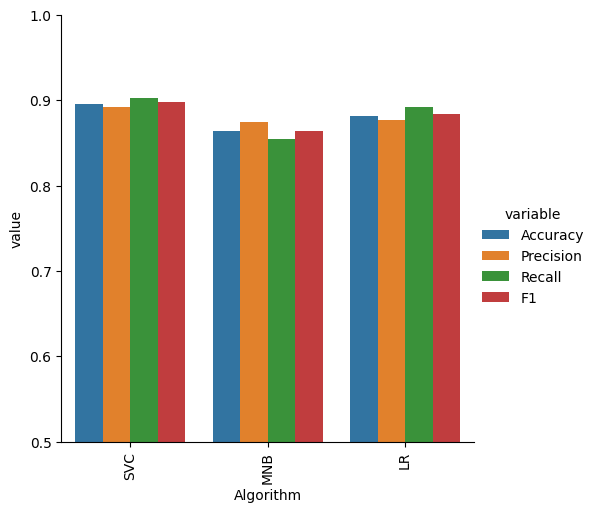

In [77]:
sns.catplot(x='Algorithm',y='value',hue='variable',data=performance_df1,kind='bar',height=5)
plt.ylim(0.5,1)
plt.xticks(rotation='vertical')
plt.show()